<a href="https://colab.research.google.com/github/alisha-q/fraud-detection-shap/blob/main/notebooks/05_shap_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
project_path = "/content/drive/MyDrive/credit-card-fraud-detection-project"

Mounted at /content/drive


# Explainable Credit Card Fraud Detection - SHAP Explainability

**Module:** 3 - Explainability with SHAP

**Goal:** Apply SHAP (Lundberg & Lee, 2017) to the selected final model to generate both
global feature importance and individual (local) prediction explanations, and serialize the
explainer for use in the Streamlit app (Interim Report, Section 4.4).

In [2]:
%pip install shap -q

import numpy as np, pandas as pd, pickle
import matplotlib.pyplot as plt
import shap

with open(f"{project_path}/models/preprocessed_splits.pkl", "rb") as f:
    splits = pickle.load(f)
X_test, y_test = splits["X_test"], splits["y_test"]
FEATURE_COLUMNS = splits["feature_columns"]

with open(f"{project_path}/models/xgboost_model.pkl", "rb") as f:
    model = pickle.load(f)

print(f"Explaining model: {type(model).__name__} on {X_test.shape[0]:,} test transactions")

Explaining model: XGBClassifier on 42,722 test transactions


---
## 1) Build a TreeSHAP Explainer

XGBoost and Random Forest are both tree ensembles, so we use SHAP's `TreeExplainer`, which
computes **exact** Shapley values efficiently (as opposed to the sampling-based
`KernelExplainer`, which is needed for non-tree models like Logistic Regression or neural
nets).

In [3]:
explainer = shap.TreeExplainer(model)

# Use a manageable sample of the test set for the global summary plot
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_sample = X_test[sample_idx]

shap_values = explainer.shap_values(X_sample)
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (2000, 30)


---
## 2) Global Feature Importance — SHAP Summary Plot

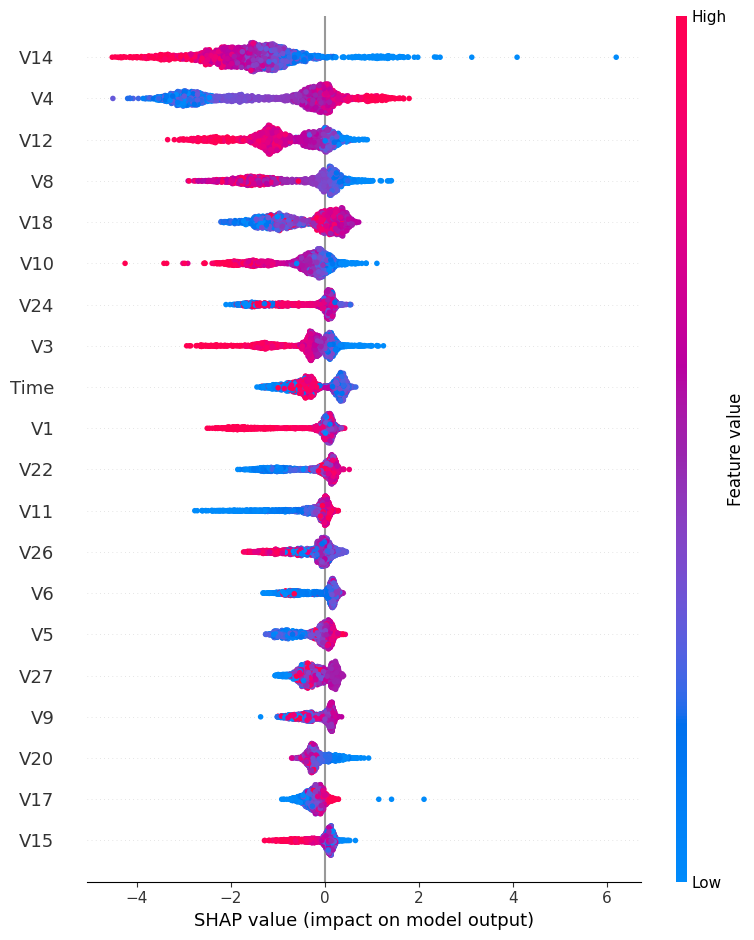

In [4]:
import pandas as pd
X_sample_df = pd.DataFrame(X_sample, columns=FEATURE_COLUMNS)

plt.figure()
shap.summary_plot(shap_values, X_sample_df, show=False)
plt.tight_layout()
plt.savefig(f"{project_path}/results/shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

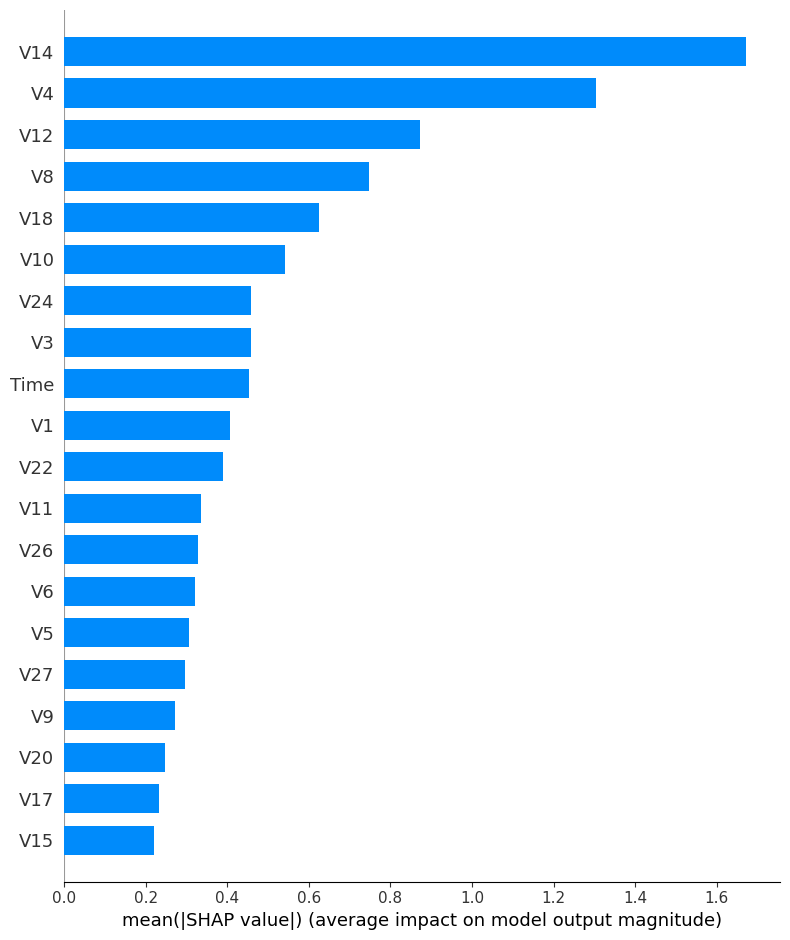

In [5]:
plt.figure()
shap.summary_plot(shap_values, X_sample_df, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(f"{project_path}/results/shap_global_importance_bar.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** the PCA-anonymized components (e.g. `V14`, `V12`, `V10`, `V17` in this
project's reference run — the specific ranking will vary once trained on the real Kaggle
data) that most influence the fraud score can be surfaced and discussed with fraud analysts
even though their original business meaning was removed for cardholder privacy (Interim
Report, Section 6, dataset note).

---
## 3) Local Explanation — Explaining a Single Prediction

Transaction index: 27295
True label: Fraud
Predicted probability of fraud: 1.0000


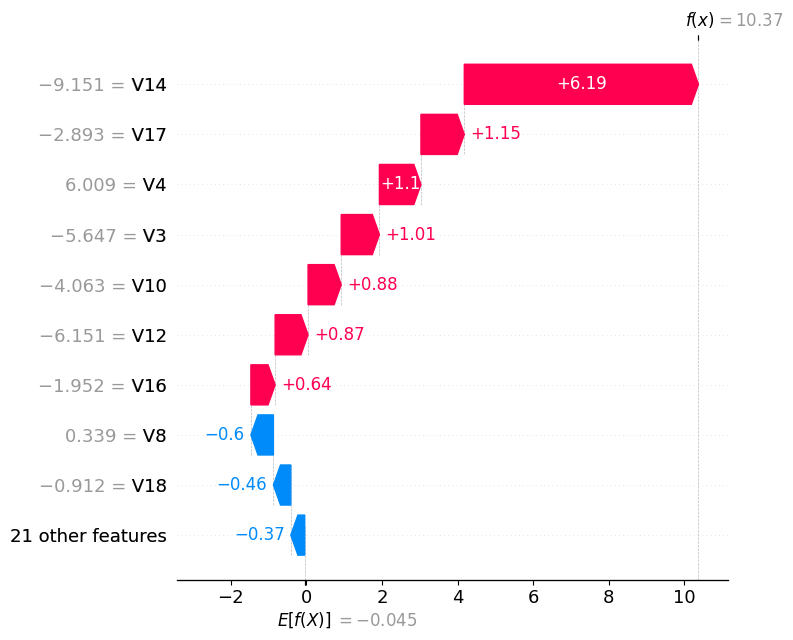

In [6]:
fraud_indices_in_sample = np.where(y_test[sample_idx] == 1)[0]
example_i = fraud_indices_in_sample[0]

print(f"Transaction index: {sample_idx[example_i]}")
print(f"True label: {'Fraud' if y_test[sample_idx[example_i]]==1 else 'Legitimate'}")
print(f"Predicted probability of fraud: {model.predict_proba(X_sample[[example_i]])[:,1][0]:.4f}")

shap.plots.waterfall(
    shap.Explanation(values=np.array(shap_values)[example_i],
                      base_values=explainer.expected_value,
                      data=X_sample[example_i],
                      feature_names=FEATURE_COLUMNS),
    show=False
)
plt.tight_layout()
plt.savefig(f"{project_path}/results/shap_waterfall_example.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 4) Feature Dependence Plot

<Figure size 640x480 with 0 Axes>

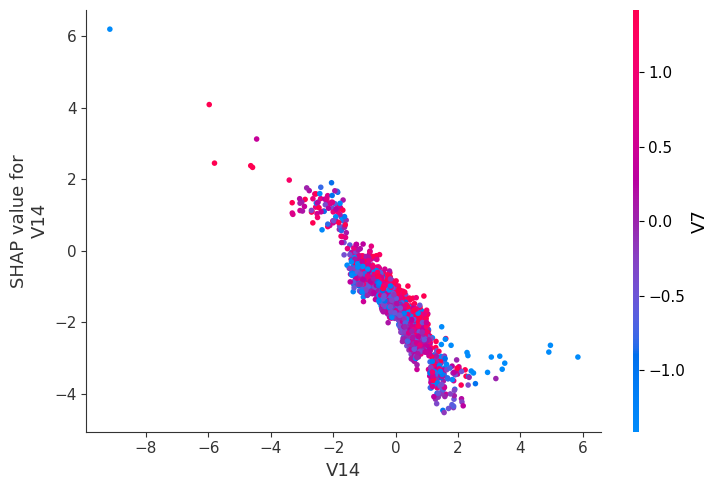

Most influential feature overall: V14


In [7]:
top_feature_idx = np.argmax(np.abs(np.array(shap_values)).mean(axis=0))
top_feature_name = FEATURE_COLUMNS[top_feature_idx]

plt.figure()
shap.dependence_plot(top_feature_idx, np.array(shap_values), X_sample_df, show=False)
plt.tight_layout()
plt.savefig(f"{project_path}/results/shap_dependence_{top_feature_name}.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Most influential feature overall: {top_feature_name}")

---
## 5) Serialize the Explainer for the Streamlit App

In [8]:
import pickle
with open(f"{project_path}/models/shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

print("Saved shap_explainer.pkl — loaded directly by app.py for real-time explanations")

Saved shap_explainer.pkl — loaded directly by app.py for real-time explanations


---
## Summary

- Built a `shap.TreeExplainer` for the selected final model (XGBoost) and computed exact
  Shapley values on a 2,000-transaction sample of the test set.
- Produced a global SHAP summary plot (beeswarm + bar chart) and a local waterfall
  explanation for an individual fraud prediction, plus a feature dependence plot for the
  single most influential feature.
- Serialized the explainer (`models/shap_explainer.pkl`) so the Streamlit app can generate
  live, per-transaction explanations without recomputing the explainer at request time.

**Next:** `app.py` — the interactive Streamlit deployment.